In [1]:
import sys

sys.path.insert(0, "..")
sys.path.insert(0, "../src")

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GroupShuffleSplit

from processing.data_cleaning import (
    build_training_arrays,
    compute_binary_class_weights,
    deduplicate_rows_by_majority_label,
)
from processing.feature_engineering import compute_can_jump, compute_raycast_sensors
from processing.frame_visualizer import FrameVisualizer
from utils import load_observations_by_session, setup_environment

In [2]:
def engineer_features(observation, session_info: dict) -> list[float]:
    """Convert one raw observation into a flat feature vector."""
    visualizer = FrameVisualizer()

    parsed_obs = visualizer.parse_observation(observation)
    grid = parsed_obs["grid"]
    sensor_values = parsed_obs["sensor_values"]

    # Base features
    can_jump_feature = compute_can_jump(sensor_values, session_info)
    sensor_features = list(sensor_values.values())

    # Raycast features
    raycasts, detected_object_types = compute_raycast_sensors(grid)

    # Object classes to track in one-hot form
    tracked_object_types = [
        visualizer.get_class_index("Empty"),
        visualizer.get_class_index("Wall"),
        visualizer.get_class_index("Spikes"),
        # visualizer.get_class_index("Dissolve Block"),
        # visualizer.get_class_index("Double Jump (Powerup)"),
        # visualizer.get_class_index("Bounce Pad"),
        # visualizer.get_class_index("Exit"),
    ]

    object_type_to_col = {
        object_type: col for col, object_type in enumerate(tracked_object_types)
    }
    object_type_one_hot = np.zeros(
        (len(detected_object_types), len(tracked_object_types)), dtype=np.float32
    )

    for row, object_type in enumerate(detected_object_types):
        col = object_type_to_col.get(object_type)
        if col is not None:
            object_type_one_hot[row, col] = 1.0

    one_hot_features = object_type_one_hot.flatten().tolist()
    return [can_jump_feature] + raycasts + one_hot_features + sensor_features

In [33]:
# 1) Load all sessions from top-level JSONL files
DATA_DIR = "../data"

all_data = {}
for i, data_file in enumerate(sorted(Path(DATA_DIR).glob("*.jsonl"))):
    observations_by_session = load_observations_by_session(data_file)
    for session_id, all_steps in observations_by_session.items():
        all_data[f"{i}_{session_id}"] = all_steps

print(f"Loaded {len(all_data)} sessions from {DATA_DIR}")


# 2) Build feature rows (one row per frame)
def build_feature_rows(observations_by_session: dict[str, list[dict]]) -> list[dict]:
    rows = []
    for session_id, all_steps in observations_by_session.items():
        session_info = {"prev_action": 0}
        for step in all_steps:
            rows.append(
                {
                    "state": engineer_features(step["state"], session_info),
                    "action": int(step["action"]),
                    "group": session_id,
                }
            )
            session_info["prev_action"] = int(step["action"])
    return rows


raw_rows = build_feature_rows(all_data)
print(f"Built {len(raw_rows)} raw training rows")

# 3) Deduplicate by feature-vector state and resolve conflicting labels
clean_rows, dedupe_stats = deduplicate_rows_by_majority_label(raw_rows)
print(
    f"Deduplicated rows: {dedupe_stats.total_samples} -> "
    f"{dedupe_stats.unique_samples} "
    f"(removed {dedupe_stats.duplicate_samples} duplicates)"
)

# 4) Convert into model arrays
X, y, groups, sample_weights = build_training_arrays(clean_rows)
print(f"X shape: {X.shape}, y shape: {y.shape}")


# 5) Session-level split (prevents leakage across frames from same recording)
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
w_train, w_test = sample_weights[train_idx], sample_weights[test_idx]

print(f"Train size: {len(train_idx)}, Test size: {len(test_idx)}")


# 6) Class weights from training fold only (same style as src/05_perceptron.py)
class_weights = compute_binary_class_weights(y_train)
print(f"Class weights: {class_weights}")

Loaded 41 sessions from ../data
Built 1180 raw training rows
Deduplicated rows: 1180 -> 505 (removed 675 duplicates)
X shape: (505, 41), y shape: (505,)
Train size: 361, Test size: 144
Class weights: {0: 1.062857142857143, 1: 1.0}


SGD Logistic accuracy (hold-out, session split): 0.788


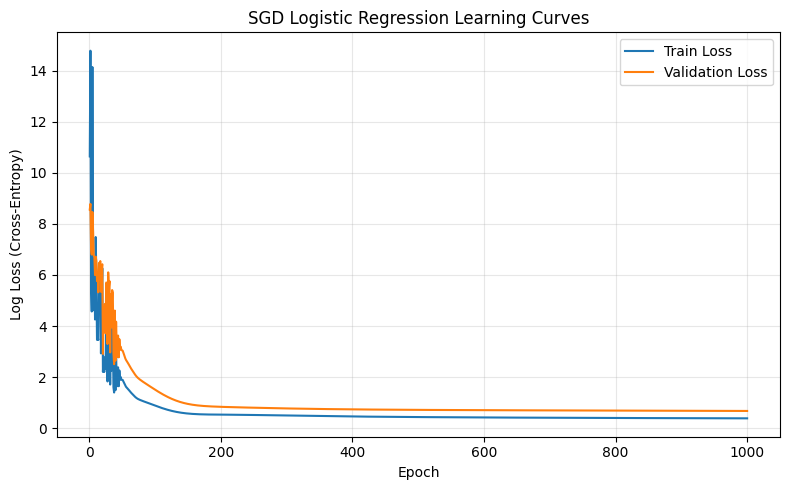

In [34]:
from sklearn.metrics import log_loss

MAX_EPOCHS = 1000                # TODO: change this if you want your AI to go fewer / more times through the data
LEARNING_RATE = 0.01             # TODO: change this if you want your AI to learn faster / slower
CLASS_WEIGHTS = class_weights    # TODO: change this if you want your AI to penalize wrong answers more / less

model = SGDClassifier(
    loss="log_loss",
    eta0=LEARNING_RATE,
    class_weight=CLASS_WEIGHTS,
    max_iter=1,
    random_state=42,
)

classes = np.unique(y_train)
train_losses = []
val_losses = []

best_val_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(MAX_EPOCHS):
    model.partial_fit(X_train, y_train, classes=classes, sample_weight=w_train)

    train_proba = model.predict_proba(X_train)
    val_proba = model.predict_proba(X_test)
    train_losses.append(log_loss(y_train, train_proba, sample_weight=w_train))
    val_losses.append(log_loss(y_test, val_proba, sample_weight=w_test))

final_accuracy = model.score(X_test, y_test, sample_weight=w_test)
print(f"SGD Logistic accuracy (hold-out, session split): {final_accuracy:.3f}")

# Plot learning curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Log Loss (Cross-Entropy)")
plt.title("SGD Logistic Regression Learning Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
def agent_brain(model, step_count, observation, session_info, done=False):
    # You need to press jump on the first frame to start walking.
    if step_count == 0 or done:
        return [1]

    engineered_features = engineer_features(observation, session_info)
    pred = model.predict([engineered_features])
    return pred

In [36]:
env = setup_environment()
obs = env.reset()
nb_agents = len(obs["obs"])

step_count = 0
session_infos = [{"prev_action": 0} for i in range(nb_agents)]
done = [False] * nb_agents
while True:
    actions = [
        agent_brain(model, step_count, obs["obs"][i], session_infos[i], done[i]) for i in range(nb_agents)
    ]
    actions = np.array(actions, dtype=np.int64)
    obs, reward, done, info = env.step(actions)

    # Update the session info for each agent
    for i, action in enumerate(actions):
        session_infos[i]["prev_action"] = action[0]

    if any(done):
        break
    step_count += 1

env.close()

python-dotenv could not parse statement starting at line 2
python-dotenv could not parse statement starting at line 3


Loaded environment variables from /Users/statieg/Personal/PLaiGROUND/src/.config
None
No game binary has been provided, please press PLAY in the Godot editor
waiting for remote GODOT connection on port 11008
connection established
action space [{'jump': {'size': 1, 'action_type': 'discrete'}}]
observation space [{'obs': {'size': [57], 'space': 'box'}}]


KeyboardInterrupt: 